--- 1. Preparación de Datos ---
Nombres de columnas estandarizados.
Se eliminaron las siguientes columnas con 100% de valores faltantes: no2_g_m3, no_g_m3, nox_g_m3, co_g_m3, so2_g_m3

Variables predictoras (features) seleccionadas: ['presion_atmosferica_mm_hg', 'temperatura_ambiente_celsius', 'velocidad_del_viento_m_s', 'direccion_del_viento', 'humedad_relativa_percent', 'radiacion_solar_w_m2', 'precipitacion_mm', 'o3_g_m3', 'trs_g_m3', 'pm10_g_m3']
Variable objetivo (target) seleccionada: pm2_5_g_m3

Dataset dividido: 7027 muestras de entrenamiento, 1757 de prueba.

--- 2. Entrenamiento del Modelo XGBoost ---
Modelo XGBoost entrenado con éxito.

--- 3. Evaluación del Modelo ---
MAE (Error Absoluto Medio): 1.55
R-squared (Coeficiente de Determinación): 0.92


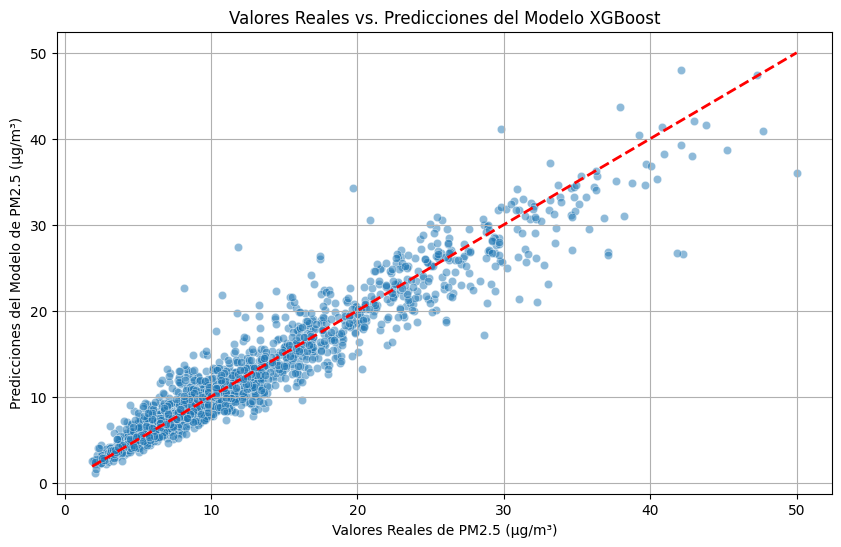

In [8]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones de limpieza y transformación de datos
def limpiar_nombres_columnas(df):
    new_columns = []
    for col in df.columns:
        # Reemplazos directos para caracteres especiales comunes
        cleaned_name = col.strip().lower()
        cleaned_name = cleaned_name.replace('(', '').replace(')', '')
        cleaned_name = cleaned_name.replace('°', '').replace(' ', '_')
        cleaned_name = cleaned_name.replace('ug/m3', 'ug_m3').replace('%', 'percent')
        cleaned_name = cleaned_name.replace('w/m2', 'w_m2').replace('m/s', 'm_s')
        cleaned_name = cleaned_name.replace('mmhg', 'mm_hg')
        
        # Normalización Unicode para eliminar cualquier otro carácter diacrítico
        cleaned_name = unicodedata.normalize('NFKD', cleaned_name).encode('ascii', 'ignore').decode('utf-8')
        
        # Limpieza final de guiones y puntos
        cleaned_name = cleaned_name.replace('.', '_').replace('/', '_')
        cleaned_name = cleaned_name.replace('__', '_').replace('__', '_').strip('_')
        
        new_columns.append(cleaned_name)
    df.columns = new_columns
    print("Nombres de columnas estandarizados.")
    return df

def manejar_datos_faltantes(df):
    df_processed = df.copy()
    
    total_rows = len(df_processed)
    cols_to_drop = [col for col in df_processed.columns if df_processed[col].isnull().sum() == total_rows]
    if cols_to_drop:
        df_processed.drop(columns=cols_to_drop, inplace=True)
        print(f"Se eliminaron las siguientes columnas con 100% de valores faltantes: {', '.join(cols_to_drop)}")
    
    initial_rows = df_processed.shape[0]
    df_processed.drop_duplicates(inplace=True)
    
    for col in df_processed.columns:
        if df_processed[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_processed[col]):
                median_val = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(median_val)
            elif df_processed[col].dtype == 'object':
                df_processed[col] = df_processed[col].fillna('DESCONOCIDO')
    
    return df_processed

def transformar_datos(df):
    df_transformed = df.copy()
    if 'fecha_y_hora' in df_transformed.columns:
        df_transformed['fecha_y_hora'] = pd.to_datetime(df_transformed['fecha_y_hora'], errors='coerce', format='%m/%d/%Y %I:%M:%S %p')
        df_transformed.dropna(subset=['fecha_y_hora'], inplace=True)
        
        df_transformed['año'] = df_transformed['fecha_y_hora'].dt.year
        df_transformed['mes'] = df_transformed['fecha_y_hora'].dt.month
        df_transformed['dia'] = df_transformed['fecha_y_hora'].dt.day
        df_transformed['hora'] = df_transformed['fecha_y_hora'].dt.hour
    
    return df_transformed


# --- Proceso Principal de Machine Learning ---

def main():
    file_path = 'Datasets/SISTEMA_DE_VIGILANCIA_DE_CALIDAD_DE_AIRE.csv'
    
    try:
        df = pd.read_csv(file_path, sep=',', na_values=['NA', '-999'])
    except FileNotFoundError:
        print(f"Error: El archivo '{file_path}' no se encontró.")
        return
        
    print("--- 1. Preparación de Datos ---")
    df_clean = limpiar_nombres_columnas(df.copy())
    df_final = manejar_datos_faltantes(df_clean)
    df_final = transformar_datos(df_final)

    # 2. SELECCIÓN DINÁMICA DE VARIABLES
    # Se define la columna objetivo (target) con el nombre correcto después de la limpieza
    target_column = 'pm2_5_g_m3'

    # Se seleccionan automáticamente las variables (features) numéricas, excluyendo el target y la fecha/hora
    # ¡Importante! 'pm2_5_g_m3' debe ser excluida de las features
    features = [
        'presion_atmosferica_mm_hg', 'temperatura_ambiente_celsius', 
        'velocidad_del_viento_m_s', 'direccion_del_viento', 'humedad_relativa_percent', 
        'radiacion_solar_w_m2', 'precipitacion_mm', 'o3_g_m3', 'trs_g_m3', 
        'pm10_g_m3'
    ]
    
    print(f"\nVariables predictoras (features) seleccionadas: {features}")
    print(f"Variable objetivo (target) seleccionada: {target_column}")
    
    # Se verifica si las columnas existen en el DataFrame
    if not all(col in df_final.columns for col in features + [target_column]):
        print("Error: Una o más columnas no se encontraron en el dataset final.")
        missing_cols = [col for col in features + [target_column] if col not in df_final.columns]
        print(f"Columnas faltantes: {missing_cols}")
        return
        
    X = df_final[features]
    y = df_final[target_column]
    
    # Dividir el dataset en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\nDataset dividido: {len(X_train)} muestras de entrenamiento, {len(X_test)} de prueba.")

    print("\n--- 2. Entrenamiento del Modelo XGBoost ---")
    model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    print("Modelo XGBoost entrenado con éxito.")
    
    print("\n--- 3. Evaluación del Modelo ---")
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print(f"MAE (Error Absoluto Medio): {mae:.2f}")
    print(f"R-squared (Coeficiente de Determinación): {r2:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title('Valores Reales vs. Predicciones del Modelo XGBoost')
    plt.xlabel('Valores Reales de PM2.5 (µg/m³)')
    plt.ylabel('Predicciones del Modelo de PM2.5 (µg/m³)')
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

# Informe Final: Modelo Predictivo de Calidad del Aire

## Introduccion:

El objetivo de esta actividad es construir un modelo de Machine Learning para predecir la concentración de partículas finas PM2.5 en el aire. Para esto, se utilizó un conjunto de datos real de un sistema de vigilancia de calidad del aire, que incluye variables meteorológicas y de otros contaminantes. El modelo busca entender la relación entre estas variables para ofrecer predicciones precisas, lo cual es de gran utilidad en la gestión ambiental y la salud pública.

## Selección del Conjunto de Datos y Justificación

Se utilizó el conjunto de datos SISTEMA_DE_VIGILANCIA_DE_CALIDAD_DE_AIRE.csv. Este dataset es ideal para un modelo predictivo por las siguientes razones:

Relevancia: Contiene variables directamente relacionadas con la calidad del aire, como temperatura, humedad, presión atmosférica y concentraciones de otros contaminantes. Esto permite identificar los factores clave que influyen en los niveles de PM2.5.

Volumen de Datos: Con más de 8,000 registros, el conjunto de datos es lo suficientemente grande para entrenar un modelo robusto que pueda identificar patrones complejos sin sobreajuste.

Objetivo: La concentración de PM2.5 es una variable continua, lo que la convierte en un objetivo perfecto para un problema de regresión.

Se eligió el algoritmo XGBoost (Extreme Gradient Boosting) por su gran desempeño en problemas de regresión con datos tabulares. A diferencia de un modelo lineal simple, XGBoost es un método de ensamble basado en árboles de decisión que construye el modelo de forma secuencial, corrigiendo los errores de los árboles anteriores.

Su principal ventaja radica en su capacidad para manejar relaciones no lineales y su eficiencia computacional. Es un algoritmo de referencia en la industria para lograr alta precisión, incluso con conjuntos de datos complejos.

## Proceso de Construcción y Resultados

Se siguió un proceso estructurado para construir el modelo:

1. Preparación de Datos: Se estandarizaron los nombres de las columnas, se eliminaron las columnas con 100% de valores faltantes y se imputaron los valores restantes. Se transformó la variable de fecha y hora para extraer el año, mes, día y hora, lo que ayuda al modelo a capturar patrones temporales.

2. División de Datos: El dataset se dividió en conjuntos de entrenamiento (80%) y prueba (20%) para evaluar el modelo en datos que no ha visto.

3. Entrenamiento: Se entrenó el modelo XGBRegressor con las variables predictoras (features) y la variable objetivo (target) seleccionadas.

4. Evaluación: Se calcularon dos métricas clave para evaluar el rendimiento del modelo en el conjunto de prueba.

    MAE (Error Absoluto Medio): 1.55. Indica que, en promedio, la diferencia entre los valores reales de PM2.5 y las predicciones del modelo es de solo 1.55 µg/m³. Un valor bajo como este demuestra una alta precisión.

    R-squared (R²): 0.92. Este coeficiente de determinación significa que el modelo explica el 92% de la variabilidad en los datos de PM2.5. Un valor tan cercano a 1.0 es excelente e indica que el modelo se ajusta muy bien a los datos.